# Olist E-Commerce Analysis


## Objetivo
Analisar os dados de vendas para identificar concentração de receita, padrões ao longo do tempo e desempenho por região, gerando insights acionáveis para o negócio.

## IMPORTS

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

## DATA LOADING

In [5]:
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_length_cm,product_height_cm,product_width_cm,payment_value,customer_id,order_purchase_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,28.0,9.0,14.0,72.19,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,50.0,30.0,40.0,259.83,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,33.0,13.0,33.0,216.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,16.0,10.0,15.0,25.78,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,35.0,40.0,30.0,218.04,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


## DATA OVERVIEW

In [ ]:
df.info()
df.describe()

# ANÁLISES

## 📈 1. RECEITA AO LONGO DO TEMPO

<Axes: title={'center': 'Revenue Over Time'}, xlabel='month'>

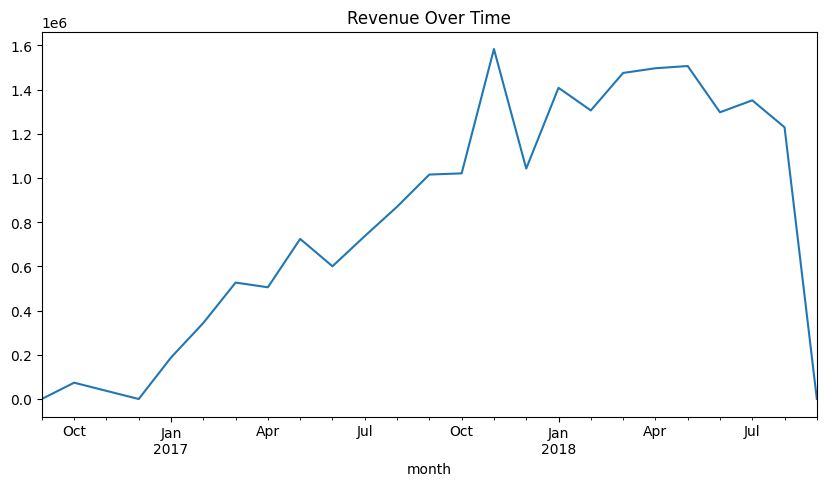

In [29]:
# Revenue over time
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["month"] = df["order_purchase_timestamp"].dt.to_period("M")

monthly_revenue = df.groupby("month")["payment_value"].sum()

growth = monthly_revenue.pct_change()

avg_growth = growth.mean()
volatility = growth.std()

max_growth = growth.max()
min_growth = growth.min()

monthly_revenue.plot(figsize=(10,5), title="Revenue Over Time")

## 📈 Dinâmica de Receita — Crescimento, Volatilidade e Previsibilidade

### Insight

- Crescimento médio mensal: **42,53%**
- Volatilidade (desvio padrão): **199,39%**
- Maior crescimento mensal: **+9569,82%**
- Maior queda mensal: **-99,98%**

### Interpretação

A volatilidade da receita é ~4,7x superior ao crescimento médio, indicando instabilidade estrutural.

### Implicação de Negócio

- Baixa previsibilidade de receita  
- Dependência de eventos pontuais  

### Ação Recomendada

- Identificar e replicar drivers de crescimento  
- Reduzir volatilidade com estratégias recorrentes  

# 📊 2. RECEITA POR CATEGORIA

<Axes: title={'center': 'Top Categories'}, xlabel='product_category_name'>

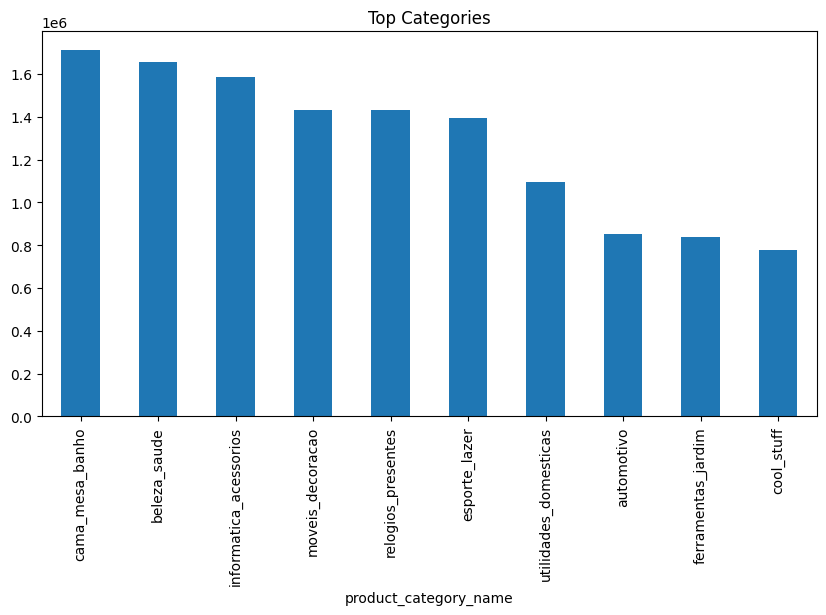

In [30]:
revenue_by_category = (
    df.groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

total_revenue = revenue_by_category.sum()

top_5_pct = revenue_by_category.head(5).sum() / total_revenue
top_10_pct = revenue_by_category.head(10).sum() / total_revenue

revenue_by_category.head(10).plot(kind="bar", figsize=(10,5), title="Top Categories")

## 📊 Concentração de Receita — Dependência do Portfólio

### Insight

- Top 5 categorias: **38,97% da receita total**
- Top 10 categorias: **63,68% da receita total**

### Interpretação

Alta concentração de receita em poucas categorias.

### Implicação de Negócio

- Crescimento rápido possível  
- Alto risco de dependência  

### Ação Recomendada

- Maximizar categorias líderes  
- Desenvolver categorias secundárias  

# 🌍 3. RECEITA POR ESTADO

<Axes: title={'center': 'Revenue by State'}, xlabel='customer_state'>

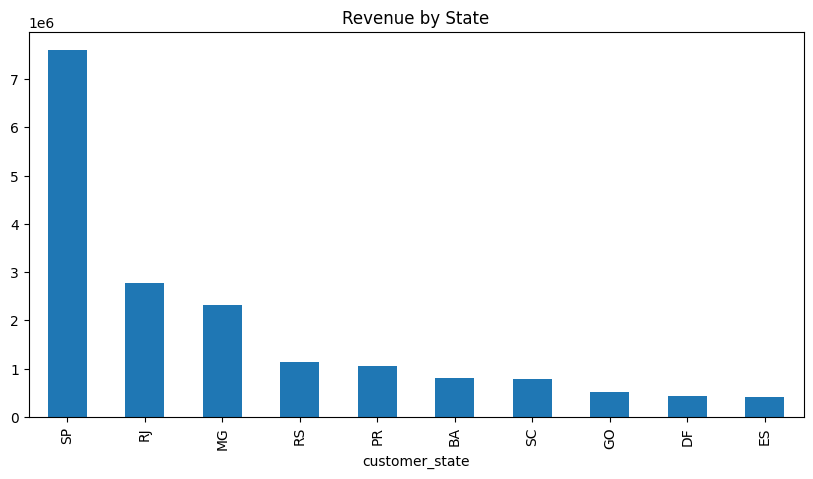

In [31]:
revenue_by_state = (
    df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_state.head(10).plot(kind="bar", figsize=(10,5), title="Revenue by State")

## 🌍 Concentração Regional — Estrutura de Mercado

### Insight

- SP representa ~37% da receita  
- Top 3 estados representam ~63%  

### Interpretação

Forte concentração geográfica.

### Implicação de Negócio

- Risco regional  
- Limitação de crescimento  

### Ação Recomendada

- Expandir para novos estados  
- Otimizar regiões principais  

# 💰 4. TICKET MÉDIO

In [32]:
total_revenue = df["payment_value"].sum()
total_orders = df["order_id"].nunique()

avg_ticket = total_revenue / total_orders

total_revenue, total_orders, avg_ticket

(np.float64(20308134.71), 98665, np.float64(205.82916647240663))

## 💰 Eficiência de Monetização — Ticket Médio

### Insight

- Receita total: **R$ 20,3M**
- Pedidos: **98.665**
- Ticket médio: **R$ 205,83**

### Interpretação

Ticket médio consistente com potencial de crescimento.

### Implicação de Negócio

- Crescimento via volume ou ticket  

### Ação Recomendada

- Upsell  
- Cross-sell  
- Bundles  

# ⭐ 5. REVIEWS VS RECEITA

<Axes: title={'center': 'Revenue by Review Score'}, xlabel='review_score'>

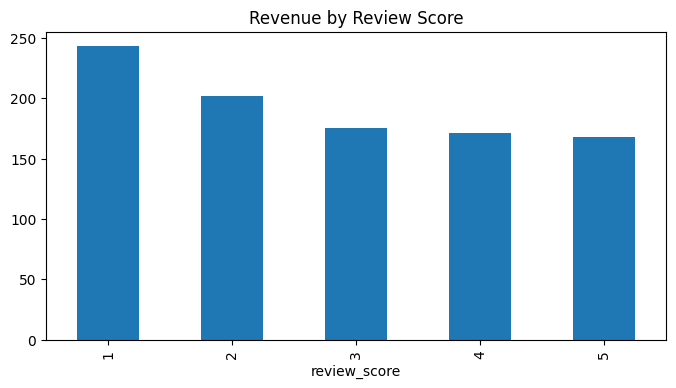

In [33]:
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

df_reviews = df.merge(reviews, on="order_id")

rating_revenue = df_reviews.groupby("review_score")["payment_value"].mean()

rating_revenue.plot(kind="bar", figsize=(8,4), title="Revenue by Review Score")

## ⭐ Qualidade vs Receita — Risco de Sustentabilidade

### Insight

- 1 estrela: **R$ 242,85**
- 5 estrelas: **R$ 167,75**

### Interpretação

Produtos com pior avaliação geram maior receita média.

### Implicação de Negócio

- Possível problema em produtos de alto valor  
- Risco de insatisfação do cliente  

### Ação Recomendada

- Melhorar qualidade dos produtos premium  
- Investigar causas de baixa avaliação  

---


# 📊 Executive Summary — Olist Sales Performance Analysis

---

## 🧭 Contexto

Esta análise tem como objetivo avaliar o desempenho de vendas da Olist, identificando padrões de crescimento, concentração de receita e possíveis riscos operacionais, com foco em geração de insights acionáveis para o negócio.

---

## 📈 1. Crescimento com Baixa Previsibilidade

A receita apresenta crescimento médio mensal de **42,53%**, porém com volatilidade extremamente elevada (**199,39%**), indicando um modelo de crescimento instável.

Esse comportamento sugere que o desempenho financeiro é impulsionado por **eventos pontuais**, e não por uma trajetória consistente de expansão.

### Impacto

- Dificuldade em prever receita  
- Risco elevado no planejamento financeiro  
- Dependência de picos de performance  

---

## 📊 2. Forte Dependência de Categorias Específicas

A análise de portfólio mostra que:

- **63,68% da receita** está concentrada em apenas 10 categorias  
- As categorias líderes são responsáveis pela maior parte do faturamento  

### Impacto

- Alta eficiência para crescimento no curto prazo  
- Risco estrutural de dependência  

---

## 🌍 3. Concentração Geográfica da Receita

A receita está altamente concentrada em regiões específicas:

- **São Paulo representa ~37% da receita total**  
- Os 3 principais estados concentram cerca de **63% da receita**

### Impacto

- Forte dependência de mercados maduros  
- Potencial limitado de crescimento se não houver expansão  

---

## 💰 4. Monetização Consistente com Potencial de Expansão

O ticket médio atual é de **R$ 205,83**, indicando um bom nível de monetização por pedido.

### Impacto

- Possibilidade de crescimento via aumento de volume  
- Oportunidade clara de elevar ticket médio com estratégias comerciais  

---

## ⚠️ 5. Risco Crítico: Receita vs Satisfação do Cliente

Um dos achados mais relevantes é a relação inversa entre avaliação do cliente e receita:

- Produtos com **1 estrela geram maior receita média (R$ 242,85)**  
- Produtos com **5 estrelas geram menor receita média (R$ 167,75)**  

### Interpretação

Esse padrão indica um possível desalinhamento entre **preço, expectativa e entrega de valor**, especialmente em produtos de maior ticket.

### Impacto

- Risco de insatisfação e churn  
- Possível deterioração da reputação da marca  
- Impacto negativo na sustentabilidade do crescimento  

---

## 🧠 Diagnóstico Geral

O negócio apresenta:

✔ Forte geração de receita  
✔ Capacidade de crescimento acelerado  
✔ Categorias bem estabelecidas  

Porém com riscos estruturais relevantes:

⚠ Alta volatilidade  
⚠ Concentração excessiva (produto + região)  
⚠ Possível problema de qualidade em produtos de maior valor  

---

## 🚀 Recomendações Estratégicas

### Curto Prazo (Ganho Rápido)

- Replicar fatores que impulsionaram picos de receita  
- Intensificar investimento nas categorias líderes  
- Otimizar performance nas principais regiões  

---

### Médio Prazo (Sustentabilidade)

- Diversificar portfólio de categorias  
- Expandir atuação geográfica  
- Implementar estratégias para aumentar previsibilidade  

---

### Longo Prazo (Escala)

- Corrigir desalinhamento entre preço e experiência do cliente  
- Estruturar crescimento baseado em consistência, não em picos  
- Monitorar satisfação como métrica estratégica  

---

## 📌 Conclusão

A Olist apresenta um modelo de crescimento com alto potencial, porém sustentado por variáveis instáveis e concentradas.

A capacidade de transformar esse crescimento em algo previsível e escalável dependerá diretamente da **redução de volatilidade, diversificação de receita e melhoria da experiência do cliente**.